In [1]:
file_path = '/home/jeppethybo/connect_public/Grendel_files/SIDR_lu_blend_T_5/'
file_name = '2026-02-19_200000__2.txt'
full_path = file_path + file_name
header_path = '/home/jeppethybo/connect_public/Grendel_files/SIDR_lu_blend_T_5/2026-02-19_200000_.paramnames'

In [2]:
import pandas as pd
df = pd.read_csv(full_path, sep=r"\s+", header=None, engine="python")

with open(header_path, 'r') as f:
    header = [line.split()[0] for line in f.readlines()]

column_names = ["step", "-loglike"] + header
df.columns = column_names
print("Data columns:", df.shape[1])
print("Header names:", len(column_names))

Data columns: 27
Header names: 27


In [3]:
columns_to_plot = column_names[1::9][:2]
print("Columns to plot:", columns_to_plot)

keep_every_x_point = 1

x = pd.to_numeric(df[columns_to_plot[1]], errors='coerce').iloc[::keep_every_x_point]
y = pd.to_numeric(df[columns_to_plot[0]], errors='coerce').iloc[::keep_every_x_point]

mask = ~x.isna() & ~y.isna()
x = x[mask]
y = y[mask]

x_test = df[columns_to_plot[1]]
y_test = df[columns_to_plot[0]]

print('min value of log10G_eff_ncdm_interacting:', x.min())
print('max_value of log10G_eff_ncdm_interacting:', x.max())
print('min value of -loglike:', y.min())
print('max value of -loglike:', y.max())



Columns to plot: ['-loglike', 'log10G_eff_ncdm_interacting']
min value of log10G_eff_ncdm_interacting: -4.999751
max_value of log10G_eff_ncdm_interacting: -1.091589
min value of -loglike: 10134.7
max value of -loglike: 11880.6


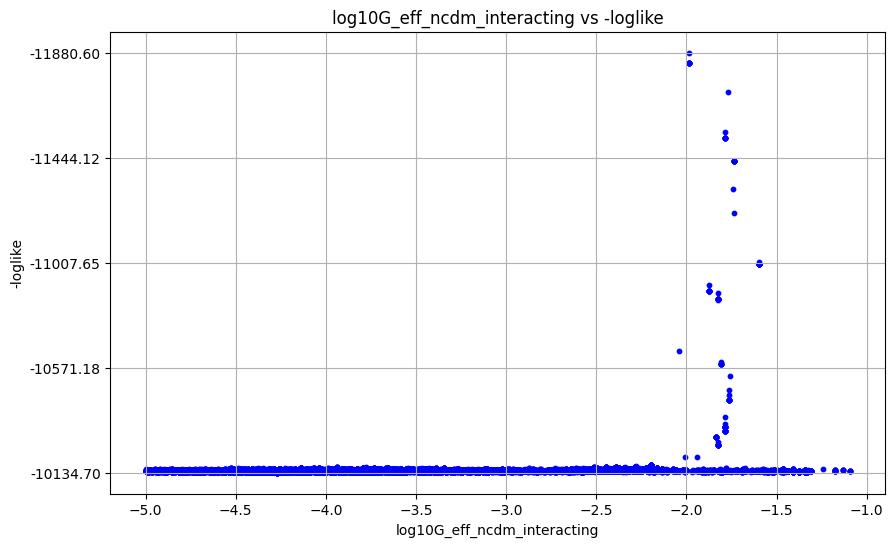

56328 56328


In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, marker='o', linestyle='-', color='blue')
plt.title(f'{columns_to_plot[1]} vs {columns_to_plot[0]}')
plt.xlabel(columns_to_plot[1])
plt.ylabel(columns_to_plot[0])
yticks= np.linspace(y.min(), y.max(), 5)
plt.yticks(yticks, labels=[f"-{tick:.2f}" for tick in yticks])

plt.grid()
plt.show()

print(len(x), len(y))

In [15]:
import pandas as pd
from pathlib import Path

# --- Paths ---
folder = Path("/home/jeppethybo/connect_public/Grendel_files/SIDR_lu_blend_T_5/")
header_path = folder / "2026-02-19_200000_.paramnames"

# --- Read header ---
with open(header_path, "r") as f:
    header = [line.split()[0] for line in f.readlines()]

# Column names: first two columns + rest from header
column_names = ["step", "-loglike"] + header
print("Column names from files:")
print(column_names)

# --- Read all txt files matching pattern ---
txt_files = sorted(folder.glob("2026-02-19_200000__*.txt"))  # 6 files
dfs = []

for file in txt_files:
    df = pd.read_csv(file, sep=r"\s+", header=None, engine="python")
    df.columns = column_names
    dfs.append(df)

# Combine all files into one DataFrame
combined_df = pd.concat(dfs, ignore_index=True)
print("\nCombined DataFrame shape:", combined_df.shape)

# --- Choose x and y columns ---
# Using your example: column_names[1] = "-loglike", column_names[10] = "log10G_eff_ncdm_interacting"
x_col = "log10G_eff_ncdm_interacting"
y_col = "-loglike"

# Convert to numeric and remove NaNs
x = pd.to_numeric(combined_df[x_col], errors='coerce')
y = pd.to_numeric(combined_df[y_col], errors='coerce')
mask = ~x.isna() & ~y.isna()
x = x[mask]
y = y[mask]

# --- Compute ranges ---
print(f"\nX column ({x_col}) range: {x.min():.5f} to {x.max():.5f}")
print(f"Y column ({y_col}) range: {y.min():.5f} to {y.max():.5f}")
print("shape of x and y:", x.shape, y.shape)

Column names from files:
['step', '-loglike', 'omega_b', 'omega_cdm', '100theta_s', 'ln10^{10}A_s', 'n_s', 'tau_reio', 'r', 'm_ncdm_interacting', 'log10G_eff_ncdm_interacting', 'deg_ncdm_interacting', 'A_planck', 'M', 'BBdust', 'BBsync', 'BBalphadust', 'BBbetadust', 'BBalphasync', 'BBbetasync', 'BBdustsynccorr', 'H0', 'sigma8', 'Omega_Lambda', 'YHe', 'A_s', 'z_reio']

Combined DataFrame shape: (336919, 27)

X column (log10G_eff_ncdm_interacting) range: -4.99992 to -0.96311
Y column (-loglike) range: 10134.70000 to 12347.80000
shape of x and y: (336757,) (336757,)


Column names:
['step', '-loglike', 'omega_b', 'omega_cdm', '100theta_s', 'ln10^{10}A_s', 'n_s', 'tau_reio', 'r', 'm_ncdm_interacting', 'log10G_eff_ncdm_interacting', 'deg_ncdm_interacting', 'A_planck', 'M', 'BBdust', 'BBsync', 'BBalphadust', 'BBbetadust', 'BBalphasync', 'BBbetasync', 'BBdustsynccorr', 'H0', 'sigma8', 'Omega_Lambda', 'YHe', 'A_s', 'z_reio']


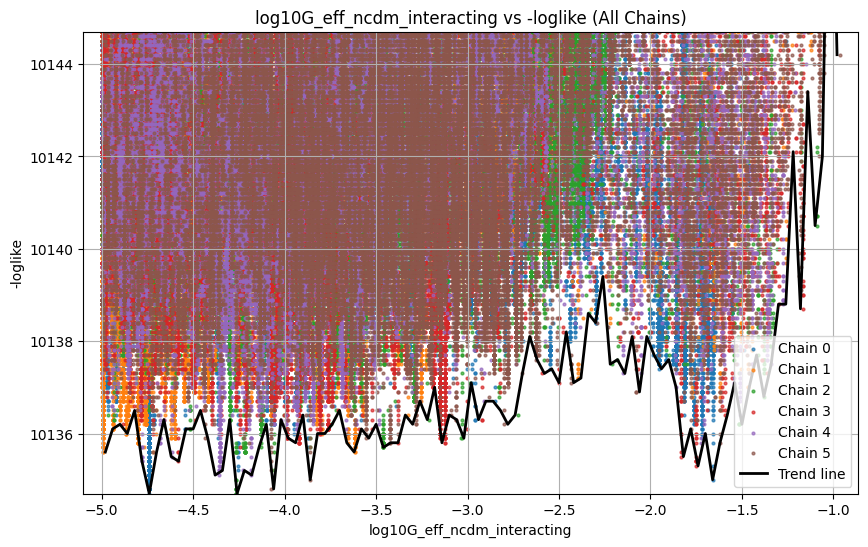

Global x range (log10G_eff_ncdm_interacting): -4.99992 to -0.96311
Global y range (-loglike): 10134.70000 to 12347.80000


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- PATHS ---------------- #
folder = Path("/home/jeppethybo/connect_public/Grendel_files/SIDR_lu_blend_T_5/")
header_path = folder / "2026-02-19_200000_.paramnames"

# ---------------- READ HEADER ---------------- #
with open(header_path, "r") as f:
    header = [line.split()[0] for line in f.readlines()]
column_names = ["step", "-loglike"] + header
print("Column names:")
print(column_names)

# ---------------- LOAD ALL FILES ---------------- #
txt_files = sorted(folder.glob("2026-02-19_200000__*.txt"))
dfs = []

# For plotting
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10.colors  # 10 distinct colors
all_data_x = []
all_data_y = []

for i, file in enumerate(txt_files):
    df = pd.read_csv(file, sep=r"\s+", header=None, engine="python")
    df.columns = column_names
    dfs.append(df)

    # Extract x and y
    x_chain = pd.to_numeric(df["log10G_eff_ncdm_interacting"], errors='coerce')
    y_chain = pd.to_numeric(df["-loglike"], errors='coerce')
    mask = ~x_chain.isna() & ~y_chain.isna()
    x_chain = x_chain[mask]
    y_chain = y_chain[mask]

    all_data_x.append(x_chain)
    all_data_y.append(y_chain)

    label = f"Chain {i}"  # label for legend
    plt.scatter(x_chain, y_chain, s=4, alpha=0.7, color=colors[i % len(colors)], marker='o', label=label)
    
plt.legend(loc='upper left')

# ---------------- COMBINE ALL DATA ---------------- #
combined_x = pd.concat(all_data_x, ignore_index=True)
combined_y = pd.concat(all_data_y, ignore_index=True)

# ---------------- SORT AND BIN FOR TREND LINE ---------------- #
sort_idx = np.argsort(combined_x)
x_sorted = combined_x.iloc[sort_idx]
y_sorted = combined_y.iloc[sort_idx]

bins_width = 0.04
bins = np.arange(x_sorted.min(), x_sorted.max() + bins_width, bins_width)

trend_x = []
trend_y = []

for i in range(len(bins) - 1):
    mask_bin = (x_sorted >= bins[i]) & (x_sorted < bins[i + 1])
    y_in_bin = y_sorted[mask_bin]
    if len(y_in_bin) > 0:
        trend_y.append(y_in_bin.min())  # minimum y in bin
        trend_x.append((bins[i] + bins[i + 1]) / 2)

trend_x = np.array(trend_x)
trend_y = np.array(trend_y)

# ---------------- TREND LINE ---------------- #
plt.plot(trend_x, trend_y, color='black', linestyle='-', linewidth=2, label='Trend line')

# ---------------- FINAL PLOT SETTINGS ---------------- #
plt.title('log10G_eff_ncdm_interacting vs -loglike (All Chains)')
plt.xlabel('log10G_eff_ncdm_interacting')
plt.xlim(combined_x.min() - 0.1, combined_x.max() + 0.1)
plt.ylim(combined_y.min(), combined_y.min() + 10)
plt.ylabel('-loglike')
plt.grid(True)
plt.legend()
plt.show()

# ---------------- PRINT RANGES ---------------- #
print(f"Global x range (log10G_eff_ncdm_interacting): {combined_x.min():.5f} to {combined_x.max():.5f}")
print(f"Global y range (-loglike): {combined_y.min():.5f} to {combined_y.max():.5f}")